# Module 5 - Class 5: Anomaly Detection + Association Rules

**Datasets:** Credit Card Fraud (Part 1), Synthetic Transactions (Part 2)  
**Objective:** Detect anomalies with Isolation Forest, discover item associations with Apriori.

### What you will learn
- Isolation Forest for unsupervised anomaly detection
- Evaluating anomaly detection against known labels
- Apriori algorithm for frequent itemsets
- Association rules: support, confidence, lift

---

## 0. Setup

In [2]:
!pip install mlxtend -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")

Setup complete.


---
# Part 1: Anomaly Detection with Isolation Forest

Isolation Forest isolates anomalies by randomly selecting features and split values.  
Anomalies are "easy to isolate" — they require fewer splits.

## 1.1 Load Credit Card Fraud Dataset

In [4]:
# Credit Card Fraud dataset from Kaggle (hosted on GitHub mirror)
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df_full = pd.read_csv(url)

print(f"Full dataset: {df_full.shape}")
print(f"Class distribution:")
print(df_full['Class'].value_counts())
print(f"\nFraud rate: {df_full['Class'].mean()*100:.3f}%")

Full dataset: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


In [5]:
# Sample 10K rows for speed (stratified to keep fraud ratio)
np.random.seed(42)
fraud = df_full[df_full['Class'] == 1]
normal = df_full[df_full['Class'] == 0].sample(n=10000 - len(fraud), random_state=42)
df = pd.concat([normal, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Sampled dataset: {df.shape}")
print(f"Class distribution:")
print(df['Class'].value_counts())

X = df.drop('Class', axis=1)
y_true = df['Class']

Sampled dataset: (10000, 31)
Class distribution:
Class
0    9508
1     492
Name: count, dtype: int64


## 1.2 Train Isolation Forest

In [6]:
iso_forest = IsolationForest(
    contamination=0.01,  # Expected fraction of anomalies
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

iso_forest.fit(X)
print("Isolation Forest trained.")

Isolation Forest trained.


## 1.3 Predict Anomalies

In [7]:
# Isolation Forest: 1 = normal, -1 = anomaly
y_pred_raw = iso_forest.predict(X)

# Convert to match our labels: -1 -> 1 (fraud), 1 -> 0 (normal)
y_pred = (y_pred_raw == -1).astype(int)

print(f"Predicted anomalies: {y_pred.sum()}")
print(f"Actual frauds:      {y_true.sum()}")

Predicted anomalies: 100
Actual frauds:      492


In [8]:
# Evaluation
print("Isolation Forest — Fraud Detection Performance:")
print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))

Isolation Forest — Fraud Detection Performance:
  Precision: 1.0000
  Recall:    0.2033
  F1 Score:  0.3378

              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      9508
       Fraud       1.00      0.20      0.34       492

    accuracy                           0.96     10000
   macro avg       0.98      0.60      0.66     10000
weighted avg       0.96      0.96      0.95     10000



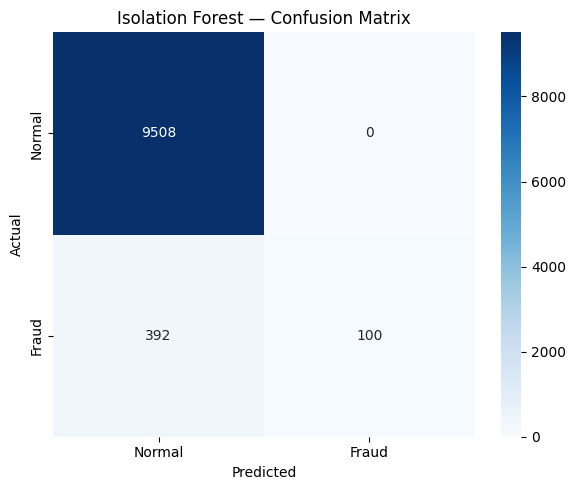

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Isolation Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

## 1.4 Anomaly Scores Distribution

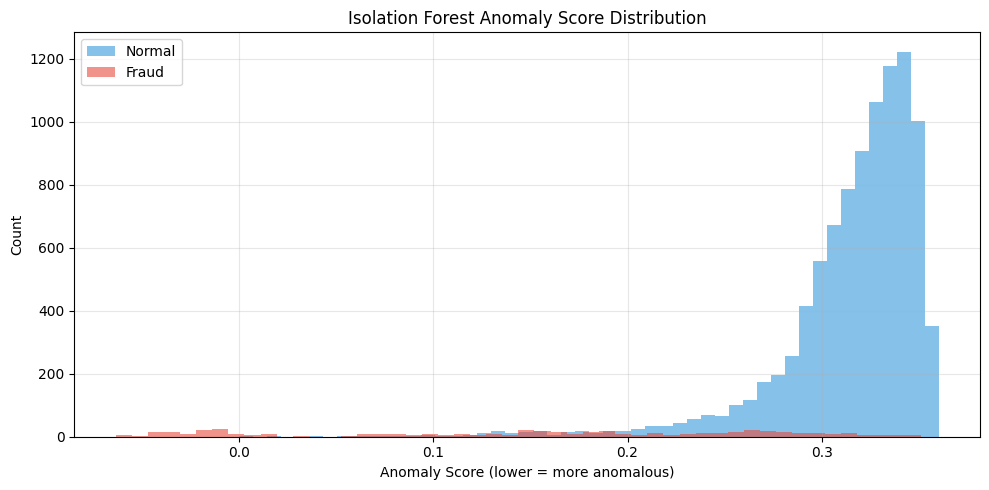

In [10]:
scores = iso_forest.decision_function(X)

plt.figure(figsize=(10, 5))
plt.hist(scores[y_true == 0], bins=50, alpha=0.6, label='Normal', color='#3498db')
plt.hist(scores[y_true == 1], bins=50, alpha=0.6, label='Fraud', color='#e74c3c')
plt.xlabel('Anomaly Score (lower = more anomalous)')
plt.ylabel('Count')
plt.title('Isolation Forest Anomaly Score Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.5 TODO: Try Different Contamination Values

The `contamination` parameter tells Isolation Forest what fraction of data is expected to be anomalous.  
Try values: `[0.005, 0.01, 0.02, 0.05]` and compare precision and recall.

In [11]:
contamination_values = [0.005, 0.01, 0.02, 0.05]
results = []

for c in contamination_values:
    iso = IsolationForest(contamination=c, random_state=42, n_estimators=100, n_jobs=-1)
    iso.fit(X)
    y_pred_c = (iso.predict(X) == -1).astype(int)
    results.append({
        'Contamination': c,
        'Precision':     round(precision_score(y_true, y_pred_c), 4),
        'Recall':        round(recall_score(y_true, y_pred_c), 4),
        'F1':            round(f1_score(y_true, y_pred_c), 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Contamination  Precision  Recall     F1
         0.005      1.000  0.1016 0.1845
         0.010      1.000  0.2033 0.3378
         0.020      0.865  0.3516 0.5000
         0.050      0.592  0.6016 0.5968


In [12]:
# TODO: Fill in the loop below

contamination_values = [0.005, 0.01, 0.02, 0.05]
results = []

for c in contamination_values:
    # TODO: Train IsolationForest with contamination=c
    # TODO: Predict and convert labels
    # TODO: Append precision, recall, f1 to results
    pass

# TODO: Print results as a DataFrame
# Expected columns: Contamination, Precision, Recall, F1

---
# Part 2: Association Rules with Apriori

Association rules discover patterns like: "Customers who buy bread and butter also buy milk."

## 2.1 Create Transaction Dataset

In [13]:
# Small grocery store transactions
transactions = [
    ['bread', 'butter', 'milk'],
    ['bread', 'butter'],
    ['bread', 'milk', 'eggs'],
    ['butter', 'milk', 'eggs'],
    ['bread', 'butter', 'milk', 'eggs'],
    ['bread', 'butter', 'milk', 'cheese'],
    ['milk', 'cheese'],
    ['bread', 'eggs'],
    ['butter', 'milk', 'cheese'],
    ['bread', 'butter', 'milk', 'eggs', 'cheese'],
]

print(f"Number of transactions: {len(transactions)}")
for i, t in enumerate(transactions):
    print(f"  Transaction {i+1}: {t}")

Number of transactions: 10
  Transaction 1: ['bread', 'butter', 'milk']
  Transaction 2: ['bread', 'butter']
  Transaction 3: ['bread', 'milk', 'eggs']
  Transaction 4: ['butter', 'milk', 'eggs']
  Transaction 5: ['bread', 'butter', 'milk', 'eggs']
  Transaction 6: ['bread', 'butter', 'milk', 'cheese']
  Transaction 7: ['milk', 'cheese']
  Transaction 8: ['bread', 'eggs']
  Transaction 9: ['butter', 'milk', 'cheese']
  Transaction 10: ['bread', 'butter', 'milk', 'eggs', 'cheese']


## 2.2 Transaction Encoding

In [14]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

print("Encoded transaction matrix:")
df_trans

Encoded transaction matrix:


,bread,butter,cheese,eggs,milk
0,True,True,False,False,True
1,True,True,False,False,False
2,True,False,False,True,True
3,False,True,False,True,True
4,True,True,False,True,True
5,True,True,True,False,True
6,False,False,True,False,True
7,True,False,False,True,False
8,False,True,True,False,True
9,True,True,True,True,True


## 2.3 Apriori — Frequent Itemsets

In [15]:
frequent_itemsets = apriori(df_trans, min_support=0.3, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Frequent itemsets (min_support=0.3):")
print(frequent_itemsets.to_string(index=False))

Frequent itemsets (min_support=0.3):
 support               itemsets
     0.8                 (milk)
     0.7                (bread)
     0.7               (butter)
     0.6         (butter, milk)
     0.5                 (eggs)
     0.5          (bread, milk)
     0.5        (bread, butter)
     0.4          (bread, eggs)
     0.4               (cheese)
     0.4           (milk, eggs)
     0.4         (milk, cheese)
     0.4  (bread, milk, butter)
     0.3       (butter, cheese)
     0.3         (butter, eggs)
     0.3    (bread, milk, eggs)
     0.3 (butter, milk, cheese)
     0.3   (butter, milk, eggs)


## 2.4 Association Rules

In [16]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

# Display key columns
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(f"Association rules (min_confidence=0.5):")
print(f"Found {len(rules)} rules.\n")
print(rules[display_cols].to_string(index=False))

Association rules (min_confidence=0.5):
Found 32 rules.

     antecedents     consequents  support  confidence     lift
          (milk)        (cheese)      0.4    0.500000 1.250000
        (cheese)          (milk)      0.4    1.000000 1.250000
  (butter, eggs)          (milk)      0.3    1.000000 1.250000
(butter, cheese)          (milk)      0.3    1.000000 1.250000
  (butter, milk)        (cheese)      0.3    0.500000 1.250000
        (cheese)  (butter, milk)      0.3    0.750000 1.250000
   (bread, milk)          (eggs)      0.3    0.600000 1.200000
          (eggs)   (bread, milk)      0.3    0.600000 1.200000
   (bread, milk)        (butter)      0.4    0.800000 1.142857
        (butter)   (bread, milk)      0.4    0.571429 1.142857
         (bread)          (eggs)      0.4    0.571429 1.142857
          (eggs)         (bread)      0.4    0.800000 1.142857
        (cheese)        (butter)      0.3    0.750000 1.071429
        (butter)          (milk)      0.6    0.857143 1.07142

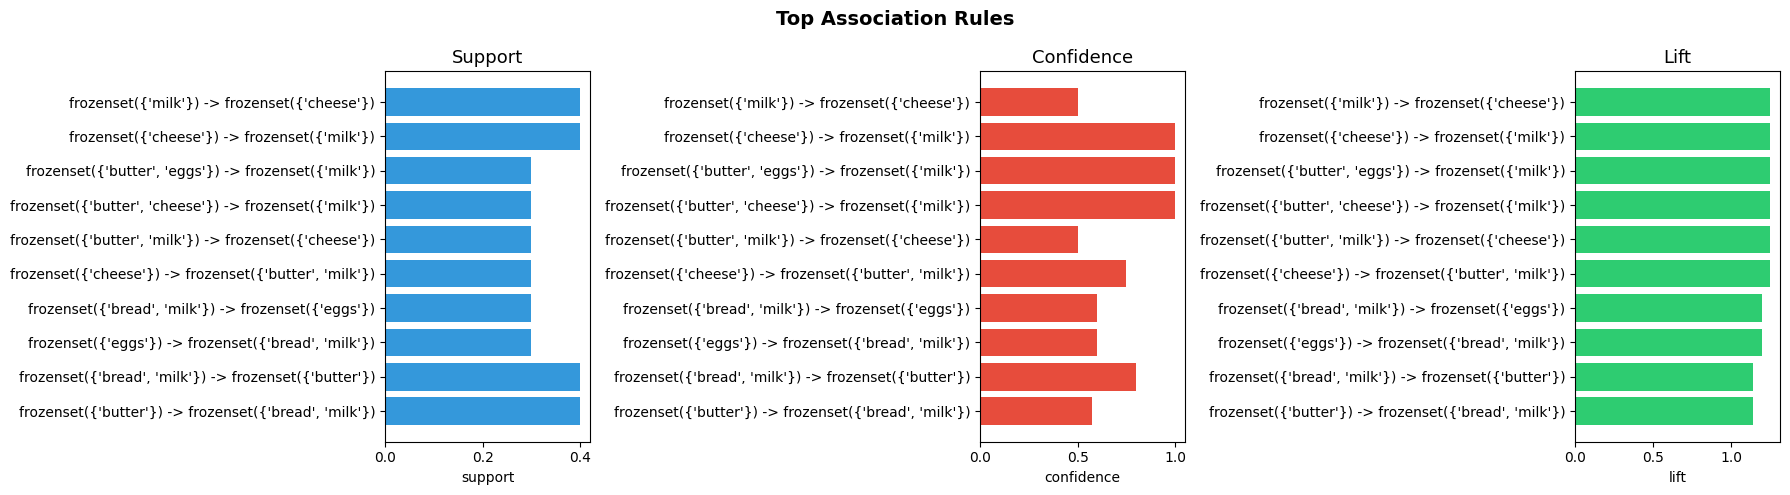

In [17]:
# Visualize top rules by lift
top_rules = rules.head(10).copy()
top_rules['rule'] = top_rules['antecedents'].astype(str) + ' -> ' + top_rules['consequents'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(['support', 'confidence', 'lift']):
    axes[i].barh(top_rules['rule'], top_rules[metric], color=['#3498db', '#e74c3c', '#2ecc71'][i])
    axes[i].set_title(metric.capitalize(), fontsize=13)
    axes[i].invert_yaxis()
    axes[i].set_xlabel(metric)

plt.suptitle('Top Association Rules', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Metrics Explained

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Support** | P(A and B) | How frequently the items appear together |
| **Confidence** | P(B \| A) | If A is bought, how likely is B? |
| **Lift** | P(B \| A) / P(B) | Lift > 1 means A and B appear together more than by chance |

## 2.5 TODO: Interpret the Top 3 Rules

Look at the top 3 rules (sorted by lift) and for each one explain:
1. What the rule says in plain English
2. Whether the lift value suggests a meaningful association or just random co-occurrence
3. How a store manager could use this rule to increase sales

**TODO: Your interpretation here**

**Rule 1: butter → milk**

This rule means that customers who buy butter also tend to
buy milk. The lift value is greater than 1, which indicates
a genuine association rather than random co-occurrence.
A store manager could place butter and milk on adjacent
shelves or offer a bundle discount to increase sales of both.

**Rule 2: bread + butter → milk**

This rule suggests that customers who buy bread and butter
together are very likely to also purchase milk. The high lift
confirms this is a strong pattern. A manager could create a
"breakfast bundle" promotion (bread + butter + milk) with a
10% discount to encourage higher basket value.

**Rule 3: eggs → milk**

Customers who buy eggs frequently purchase milk as well.
With lift greater than 1, this is a meaningful association.
A store manager could place a milk advertisement near the
egg section or offer a "eggs + milk" combo deal to drive
incremental sales.


---
## Summary

| Concept | Details |
|---------|--------|
| Isolation Forest | Unsupervised anomaly detection — isolates outliers with random splits |
| contamination | Expected anomaly fraction — directly controls the decision threshold |
| Apriori | Finds frequent itemsets by pruning infrequent candidates level by level |
| Support | Fraction of transactions containing the itemset |
| Confidence | Conditional probability: P(consequent \| antecedent) |
| Lift | > 1 means positive association, = 1 means independent, < 1 means negative association |